<a href="https://colab.research.google.com/github/growth-cct/wright-fisher-fixation/blob/main/WF_allele_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ライブラリのインポート

# time
import time

# algebra
import numpy as np
# plot
import matplotlib.pyplot as plt
# make your plot more attractive
import seaborn

N=50: mean generations = 67.47, std = 51.63, fixation probability = 0.51
N=100: mean generations = 135.80, std = 98.56, fixation probability = 0.52
N=500: mean generations = 701.55, std = 492.01, fixation probability = 0.48
N=1000: mean generations = 1406.18, std = 975.18, fixation probability = 0.52


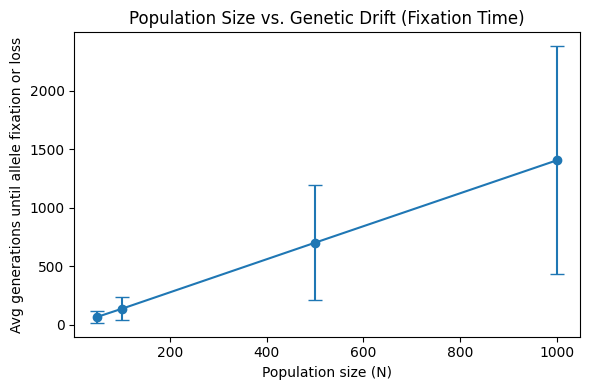

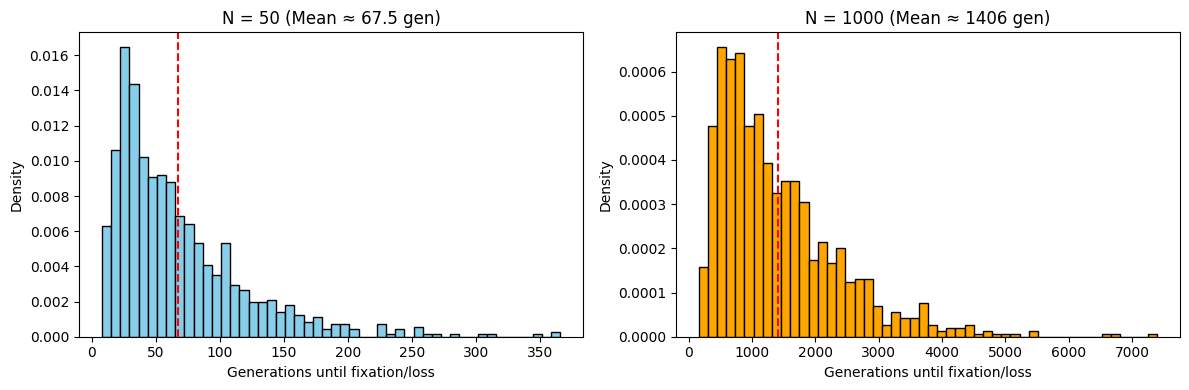

In [ ]:
# 必要なライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt

# 遺伝的浮動シミュレーション関数の定義 (次世代の対立遺伝子数を計算)&#8203;:contentReference[oaicite:14]{index=14}
def make_next_gen(num_derived, population_size):
    """
    与えられた親集団から子集団への遺伝子サンプリングを1世代行い、
    子世代の変異型対立遺伝子数を返す関数。
    """
    p = num_derived / population_size  # 親集団における変異型アレル頻度&#8203;:contentReference[oaicite:15]{index=15}
    # 子世代の変異型アレル数を二項分布からサンプリング
    next_num = np.random.binomial(population_size, p)
    return next_num

# 対立遺伝子が固定または消失するまでシミュレーションし、世代数を返す関数
def simulate_until_fixation(population_size, initial_derived):
    """
    集団サイズpopulation_sizeで、初期変異型アレル数initial_derivedから
    対立遺伝子が固定(頻度1)もしくは消失(頻度0)するまで世代を進め、
    その経過世代数と結果(固定か消失か)を返す。
    """
    derived = initial_derived
    generations = 0
    # 世代を繰り返す&#8203;:contentReference[oaicite:16]{index=16}&#8203;:contentReference[oaicite:17]{index=17}
    while 0 < derived < population_size:
        # 次世代の変異型アレル数をランダムに決定&#8203;:contentReference[oaicite:18]{index=18}&#8203;:contentReference[oaicite:19]{index=19}
        derived = make_next_gen(derived, population_size)
        generations += 1
        # 変異型アレル数derivedが0またはpopulation_sizeになったらループ終了（固定 or 消失）
    # 戻り値: 世代数 と 固定フラグ(Trueなら固定、Falseなら消失)
    return generations, (derived == population_size)

# パラメーター設定
population_sizes = [50, 100, 500, 1000]  # 調べる集団サイズのリスト（必要に応じて追加）
num_simulations = 1000  # 各集団サイズでのシミュレーション試行回数

# 結果を保存するための変数用意
results = {}  # 各集団サイズごとに平均世代数などを記録する辞書

# 各集団サイズについてシミュレーションを繰り返し実行
for N in population_sizes:
    initial_alleles = N // 2   # 初期の変異型アレル数（初期頻度0.5とする）&#8203;:contentReference[oaicite:20]{index=20}
    fixation_times = []        # 吸収(固定/消失)までの世代数を記録するリスト
    fixation_count = 0         # 固定が起こった回数をカウント
    for i in range(num_simulations):
        # 1回のシミュレーションを実行
        gens, fixed = simulate_until_fixation(N, initial_alleles)
        fixation_times.append(gens)
        if fixed:               # 固定した場合
            fixation_count += 1
    # 試行結果の統計量を計算
    fixation_times = np.array(fixation_times)
    average_generations = fixation_times.mean()           # 平均固定(消失)世代数
    std_generations = fixation_times.std()                # 標準偏差
    fixation_probability = fixation_count / num_simulations  # 固定した割合（確率）
    # 結果を辞書に保存
    results[N] = {
        'times': fixation_times,
        'mean_gen': average_generations,
        'std_gen': std_generations,
        'fix_prob': fixation_probability
    }
    # 結果の概要を表示
    print(f"N={N}: mean generations = {average_generations:.2f}, std = {std_generations:.2f}, fixation probability = {fixation_probability:.2f}")

# グラフ描画: 集団サイズごとの平均固定世代数の比較
plt.figure(figsize=(6,4))
# データ準備
Ns = list(results.keys())
means = [results[N]['mean_gen'] for N in Ns]
stds = [results[N]['std_gen'] for N in Ns]
# 平均±標準偏差のエラーバープロット
plt.errorbar(Ns, means, yerr=stds, fmt='o-', capsize=5)
plt.xlabel("Population size (N)")
plt.ylabel("Avg generations until allele fixation or loss")
plt.title("Population Size vs. Genetic Drift (Fixation Time)")
plt.tight_layout()
plt.show()

# グラフ描画: 固定までの世代数分布ヒストグラム（例: Nが小さい場合と大きい場合）
plt.figure(figsize=(12,4))
# Nが最小のケースと最大のケースを比較
smallN = Ns[0]
largeN = Ns[-1]
# 左: 小さい集団の場合のヒストグラム
plt.subplot(1,2,1)
plt.hist(results[smallN]['times'], bins=50, density=True, color='skyblue', edgecolor='black')
plt.axvline(results[smallN]['mean_gen'], color='red', linestyle='--')
plt.xlabel("Generations until fixation/loss")
plt.ylabel("Density")
plt.title(f"N = {smallN} (Mean ≈ {results[smallN]['mean_gen']:.1f} gen)")
# 右: 大きい集団の場合のヒストグラム
plt.subplot(1,2,2)
plt.hist(results[largeN]['times'], bins=50, density=True, color='orange', edgecolor='black')
plt.axvline(results[largeN]['mean_gen'], color='red', linestyle='--')
plt.xlabel("Generations until fixation/loss")
plt.ylabel("Density")
plt.title(f"N = {largeN} (Mean ≈ {results[largeN]['mean_gen']:.0f} gen)")
plt.tight_layout()
plt.show()


Pearson correlation coefficient (r): 1.0000
P-value: 1.1213e-06


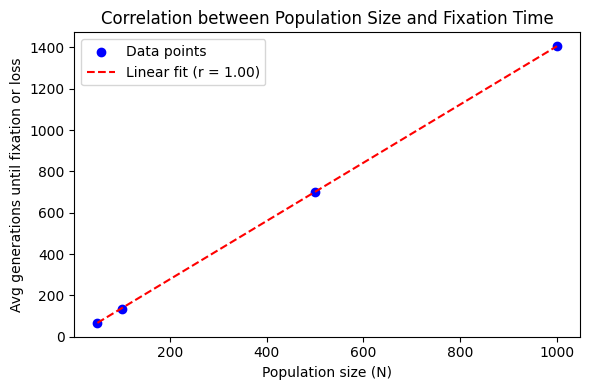

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

# 前提: 'results' 辞書がすでに定義されていて、各Nに対して平均世代数が入っている

# データ抽出
Ns = np.array(list(results.keys()))
means = np.array([results[N]['mean_gen'] for N in Ns])

# 相関係数の計算（Pearson）
r, p_value = pearsonr(Ns, means)
print(f"Pearson correlation coefficient (r): {r:.4f}")
print(f"P-value: {p_value:.4e}")

# 回帰直線の計算（線形近似）
slope, intercept, r_value, p_value_lr, std_err = linregress(Ns, means)
regression_line = slope * Ns + intercept

# プロット
plt.figure(figsize=(6,4))
plt.scatter(Ns, means, color='blue', label='Data points')
plt.plot(Ns, regression_line, color='red', linestyle='--', label=f'Linear fit (r = {r:.2f})')
plt.xlabel("Population size (N)")
plt.ylabel("Avg generations until fixation or loss")
plt.title("Correlation between Population Size and Fixation Time")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#固定までの世代数をシミュレーションする関数
import numpy as np

def simulate_fixation_time(N, initial_derived):
    generation = 0
    derived = initial_derived
    while derived > 0 and derived < N:
        p = derived / N
        derived = np.random.binomial(N, p)
        generation += 1
    return generation

#複数回のシミュレーションを実行し、平均を求める
def run_simulations(N, p_list, trials=10000):
    results = {}
    for p in p_list:
        init = int(N * p)
        times = [simulate_fixation_time(N, init) for _ in range(trials)]
        results[p] = {
            "mean": np.mean(times),
            "std": np.std(times),
            "se": np.std(times) / np.sqrt(trials)
        }
    return results


In [ ]:
#結果をプロット（平均固定時間 vs 初期頻度）
import matplotlib.pyplot as plt

def plot_fixation_times(results):
    ps = sorted(results.keys())
    means = [results[p]["mean"] for p in ps]
    errors = [results[p]["se"] for p in ps]

    plt.errorbar(ps, means, yerr=errors, fmt='o-', capsize=5)
    plt.xlabel("Initial allele frequency (p)")
    plt.ylabel("Mean generations to fixation")
    plt.title("Fixation Time vs Initial Allele Frequency (N=200)")
    plt.grid(True)
    plt.show()

#相関が得られなかったケースのプロット（例：N=200）
def plot_failure_case():
    small_N_results = run_simulations(200, [0.1, 0.3, 0.5, 0.7, 0.9], trials=10000)
    ps = sorted(small_N_results.keys())
    means = [small_N_results[p]["mean"] for p in ps]
    errors = [small_N_results[p]["se"] for p in ps]

    plt.errorbar(ps, means, yerr=errors, fmt='s--', capsize=5, color='red')
    plt.xlabel("Initial allele frequency (p)")
    plt.ylabel("Mean generations to fixation")
    plt.title("Fixation Time with Small Population (N=20)")
    plt.grid(True)
    plt.show()


Fixation times saved to 'fixation_times_N200.xlsx'.

Initial frequency p=0.1:
Mean: 126.02, SE: 1.61

Initial frequency p=0.3:
Mean: 241.43, SE: 2.01

Initial frequency p=0.5:
Mean: 276.60, SE: 2.06

Initial frequency p=0.7:
Mean: 245.45, SE: 2.04

Initial frequency p=0.9:
Mean: 127.95, SE: 1.64


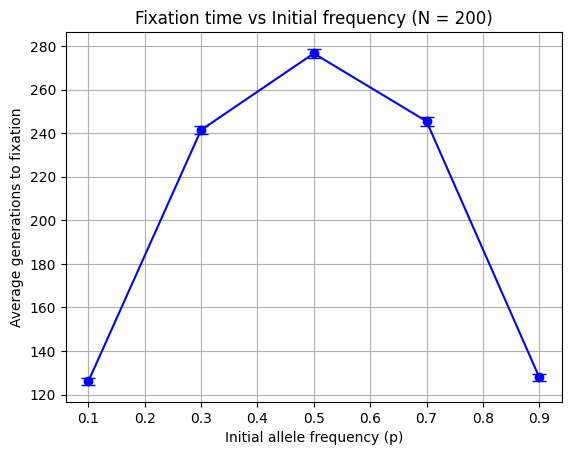

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  # Excel保存用

def simulate_fixation_time(N, initial_derived):
    generation = 0
    derived = initial_derived
    while 0 < derived < N:
        p = derived / N
        derived = np.random.binomial(N, p)
        generation += 1
    return generation

def run_simulations(N, p_list, trials=10000):
    results = {}
    for p in p_list:
        init = int(N * p)
        times = [simulate_fixation_time(N, init) for _ in range(trials)]
        results[p] = {
            "raw": times,
            "mean": np.mean(times),
            "std": np.std(times),
            "se": np.std(times) / np.sqrt(trials)
        }
    return results

def plot_main_experiment():
    N = 200
    p_list = [0.1, 0.3, 0.5, 0.7, 0.9]
    trials = 10000
    results = run_simulations(N, p_list, trials=trials)

    # データをExcelファイルで保存
    df = pd.DataFrame({f"p={p}": results[p]['raw'] for p in p_list})
    df.to_excel("fixation_times_N200.xlsx", index=False)
    print("Fixation times saved to 'fixation_times_N200.xlsx'.")

    # 結果表示
    for p in p_list:
        print(f"\nInitial frequency p={p}:")
        print(f"Mean: {results[p]['mean']:.2f}, SE: {results[p]['se']:.2f}")

    # グラフ
    ps = sorted(results.keys())
    means = [results[p]["mean"] for p in ps]
    errors = [results[p]["se"] for p in ps]

    plt.errorbar(ps, means, yerr=errors, fmt='o-', capsize=5, color='blue')
    plt.xlabel("Initial allele frequency (p)")
    plt.ylabel("Average generations to fixation")
    plt.title("Fixation time vs Initial frequency (N = 200)")
    plt.grid(True)
    plt.show()

plot_main_experiment()


In [ ]:
#第０世代

size=100
init=40

p=init/size
print('Gene frequency (0th gen): p =',p)

Gene frequency (0th gen): p = 0.4


In [ ]:
#第1世代

next=0          # initialize num of mutant alleles in the next generation

# pick up 'size' genomes
for i in range(size):

    # determine allele type
    if( np.random.rand()<p ):

        # if derived
        next+=1

# print out results
print('1st generation')
print(size-next) # ancestral type
print(next)      # derived type

1st generation
61
39


In [ ]:
#第２世代

p=next/size
print('Gene frequency (1st gen): p =',p)

next=0
for i in range(size):
    if( np.random.rand()<p ):
        next+=1

# print out
print('2nd generation')
print(size-next) # ancestral type
print(next)      # derived type

Gene frequency (1st gen): p = 0.39
2nd generation
59
41


In [ ]:
#第3世代

p=next/size
print('Gene frequency (2nd gen): p =',p)

next=0
for i in range(size):
    if( np.random.rand()<p ):
        next+=1

print('3rd generation')
print(size-next) # ancestral type
print(next)      # derived type

Gene frequency (2nd gen): p = 0.41
3rd generation
49
51


In [ ]:
#第４世代

p=next/size
print('Gene frequency (3rd gen): p =',p)

next=0
for i in range(size):
    if( np.random.rand()<p ):
        next+=1

print('4th generation')
print(size-next) # ancestral type
print(next)      # derived type

Gene frequency (3rd gen): p = 0.51
4th generation
49
51


In [ ]:
#第５世代

p=next/size
print('Gene frequency (4th gen): p =',p)

next=0
for i in range(size):
    if( np.random.rand()<p ):
        next+=1

print('5th generation')
print(size-next) # ancestral type
print(next)      # derived type

Gene frequency (4th gen): p = 0.51
5th generation
45
55


In [ ]:
#関数を定義する

def make_next_gen(derived, size=size):
    '''
    Calculate the number of derived alleles in the next generation.

    Arguments:
        derived: number of derived alleles in the parent population
        size: size of the population
    Returns:
        the number of derived alleles in the child population
    '''
    p=derived/size
    next=0
    for i in range(size):
        if( np.random.rand()<p ):
            next+=1
    return next

In [ ]:
#変異型の数をシミュレート

size = 100
init = 40
print(init)

next=make_next_gen(init, size)
print(next)

next=make_next_gen(next, size)
print(next)

next=make_next_gen(next, size)
print(next)

next=make_next_gen(next, size)
print(next)

next=make_next_gen(next, size)
print(next)

40
27
27
20
19
20


In [ ]:
# initialization
derived = 40
size = 100

# print out the initial number of derived alleles
print(derived)

# for 20 generations
for i in range(20):

    # make the next generation
    derived = make_next_gen(derived, size)

    # print out the number of derived alleles
    print(derived)

40
36
36
38
39
41
49
52
52
58
59
64
57
57
57
55
62
63
62
53
47


In [ ]:
# initialization
derived = 40
size = 100

# print out the initial number of derived alleles
print(derived/size)

# for 20 generations
for i in range(20):

    # make the next generation
    derived = make_next_gen(derived, size)

    # print out the number of derived alleles
    print(derived/size)

0.4
0.42
0.48
0.45
0.44
0.52
0.56
0.52
0.48
0.41
0.43
0.55
0.57
0.49
0.52
0.52
0.49
0.47
0.39
0.37
0.34


In [ ]:

# initialization
derived = 40
size = 100

# initialize a list
tr = []

# append the initial frequency
tr.append( derived/size )


# 50 generations
for i in range(50):

    # make next generation
    derived = make_next_gen(derived, size)

    # append freq
    tr.append( derived/size )

print(tr)

[0.4, 0.29, 0.26, 0.27, 0.35, 0.33, 0.29, 0.29, 0.25, 0.32, 0.36, 0.35, 0.37, 0.32, 0.33, 0.27, 0.28, 0.28, 0.23, 0.21, 0.22, 0.25, 0.29, 0.27, 0.32, 0.43, 0.41, 0.49, 0.54, 0.58, 0.59, 0.63, 0.63, 0.62, 0.58, 0.69, 0.64, 0.65, 0.58, 0.62, 0.62, 0.6, 0.59, 0.62, 0.62, 0.59, 0.56, 0.56, 0.49, 0.49, 0.48]


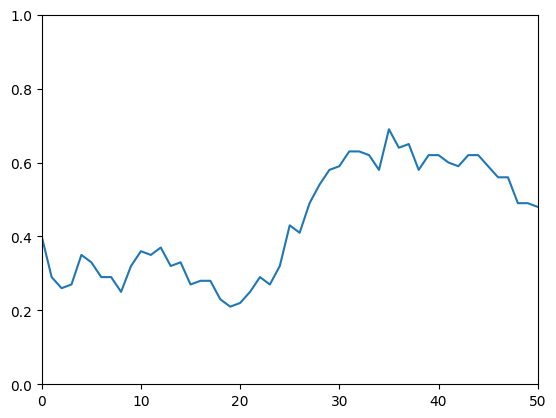

60.227 seconds


In [ ]:
#Visualization

fig=plt.figure()
ax=fig.add_subplot(1,1,1)

ax.plot(tr)

ax.set_xlim(0,50)
ax.set_ylim(0,1)
plt.show()

# a list of lists
sim = []

# set initial conditions
derived = 40
size = 100

howmany = 1000
generations = 1000

# simulation starts
t_start = time.time()

# repeat simulation 'howmany' times
for j in range(howmany):

    # reset initial condition
    derived = 40
    size = 100
    tr = [derived/size]

    # simulate frequency trajectory
    for i in range(generations):

        # make next generation
        derived = make_next_gen(derived, size)
        # append freq
        tr.append( derived/size )

    # append trajectory
    sim.append(tr)

# finished
t_end = time.time()
print( '{0:.3f} seconds'.format(t_end-t_start))

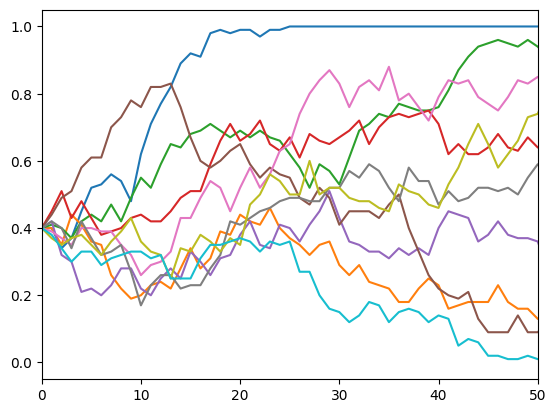

In [ ]:
#シミュレーション結果をプロット

fig=plt.figure()
ax=fig.add_subplot(111)
for i in range(10):
    ax.plot(sim[i])
ax.set_xlim(0,50)
plt.show()

In [ ]:
#頻度変化、固定確率、固定まで 消失までの待ち時間分布

fixed = []
lost = []

for i in range(len(sim)):
    trajectory = np.array(sim[i])
    if(trajectory[-1]>0):
        fixed.append( trajectory[ trajectory<1 ].shape[0] )
    else:
        lost.append( trajectory[ trajectory>0 ].shape[0] )


p_fix = len(fixed)/len(sim)
ave_fixation_time = np.average(fixed)
ave_time_until_lost = np.average(lost)

print( "the proportion of fixed trajectories is {0:.2f}".format(p_fix))
print( "the average time until fixation of the allele is {0:.2f}".format(ave_fixation_time))
print( "the average time until loss of the allele is {0:.2f}".format(ave_time_until_lost))

the proportion of fixed trajectories is 0.42
the average time until fixation of the allele is 150.40
the average time until loss of the allele is 124.39


AttributeError: Rectangle.set() got an unexpected keyword argument 'normed'

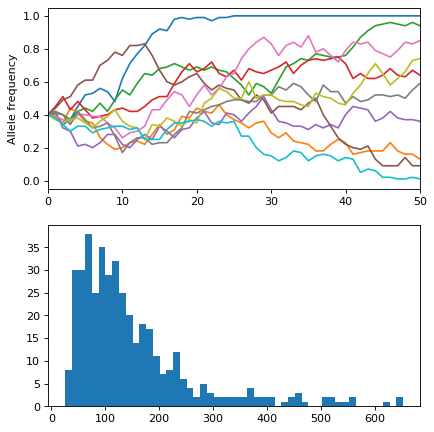

In [ ]:
#頻度変化と固定するまでの時間の分布、消失までの時間の分布

xmax=800
ymax=70

fig = plt.figure(figsize=(6,10),dpi=80)

ax1 = fig.add_subplot(3,1,1)
for i in range(10):
    ax1.plot(sim[i])
ax1.set_xlim(0,50)
ax1.set_ylabel("Allele frequency")


ax2 = fig.add_subplot(3,1,2)
ax2.hist(fixed, bins=50, normed=True)
ax2.set_xlim(0,xmax)
ax2.set_ylim(0,.01)
ax2.set_ylabel("Count")
ax2.text(500, .0060, "Time until fixation")
ax2.annotate("average ({0:.1f} generations)".format(ave_fixation_time),
             xy=(ave_fixation_time, .0030),
             xytext=(ave_fixation_time, .0050),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))


ax3 = fig.add_subplot(3,1,3)
ax3.hist(lost, bins=50, normed=True)
ax3.set_xlim(0,xmax)
ax3.set_ylim(0,0.01)

ax3.set_xlabel("Generation")
ax3.set_ylabel("Count")
ax3.text(500,.0060, "Time until lost")
ax3.annotate("average ({0:.1f} generations)".format(ave_time_until_lost),
             xy=(ave_time_until_lost, .0030),
             xytext=(ave_time_until_lost, .0050),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))



fig.tight_layout()
#fig.savefig("Drift_simulation_1.eps")
plt.show()

0.179 seconds


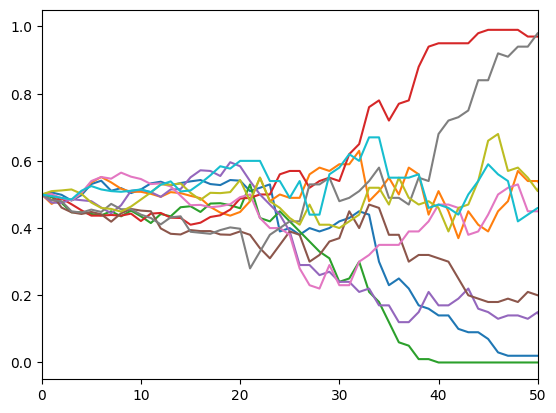

In [ ]:
#おまけ（集団サイズが減少した時）

# a list of lists
sim = []

# set initial conditions
size_ans = 1000
derived_ans = size_ans*.5


howmany = 10
generations = 100

# simulation starts
t_start = time.time()

# repeat simulation 'howmany' times
for j in range(howmany):

    # reset initial condition
    derived = derived_ans
    size = size_ans

    tr = [derived/size]

    # simulate frequency trajectory
    for i in range(generations):

        # population size change
        if i==20:
            # reduction
            size = int(size/10)
            derived = int(derived/10)

            # growth
            #size *= 10
            #derived *= 10

        # make next generation
        derived = make_next_gen(derived, size)
        # append freq
        tr.append( derived/size )

    # append trajectory
    sim.append(tr)

# finished
t_end = time.time()
print( '{0:.3f} seconds'.format(t_end-t_start))


# plot
fig=plt.figure()
ax=fig.add_subplot(111)
for i in range(10):
    ax.plot(sim[i])
ax.set_xlim(0,50)
plt.show()

0.486 seconds


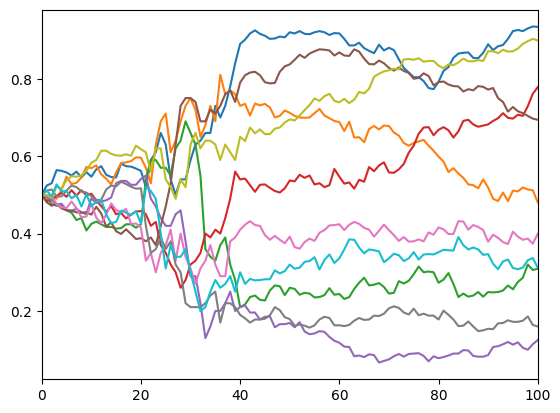

In [ ]:
#おまけ（ボトルネック）

# a list of lists
sim = []

# set initial conditions
size_ans = 1000
derived_ans = size_ans*.5

howmany = 10
generations = 100

# simulation starts
t_start = time.time()

# repeat simulation 'howmany' times
for j in range(howmany):

    # reset initial condition
    derived = derived_ans
    size = size_ans
    tr = [derived/size]

    # simulate frequency trajectory
    for i in range(generations):

        # population size change
        if i==20:
            # reduction
            size = int(size/10)
            derived = int(derived/10)

        if i==40:
            # growth
            size *= 10
            derived *= 10

        # make next generation
        derived = make_next_gen(derived, size)
        # append freq
        tr.append( derived/size )

    # append trajectory
    sim.append(tr)

# finished
t_end = time.time()
print( '{0:.3f} seconds'.format(t_end-t_start))


# plot
fig=plt.figure()
ax=fig.add_subplot(111)
for i in range(10):
    ax.plot(sim[i])
ax.set_xlim(0,100)
plt.show()